**Charger et préparer GoEmotions**

In [9]:
from datasets import load_dataset

# Charger GoEmotions (train/test/validation)
dataset = load_dataset("go_emotions")

# Afficher un exemple
print(dataset["train"][0])
# Voir la structure
print(dataset)

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [10]:
all_labels = dataset["train"].features["labels"].feature.names
print("Toutes les étiquettes :", all_labels)

# Choix d'exemple : 6 émotions principales
selected = ["joy", "sadness", "anger", "fear", "love", "surprise"]
selected_ids = [all_labels.index(l) for l in selected]
print("Selected ids:", selected_ids)

Toutes les étiquettes : ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Selected ids: [17, 25, 2, 14, 18, 26]


In [11]:
import pandas as pd

def simplify_dataset(split):
    rows = []
    for ex in dataset[split]:
        labels = ex["labels"]  # liste des IDs (multi-label)
        # trouver la première étiquette parmi nos 6 émotions sélectionnées
        chosen_label = None
        for i in selected_ids:
            if i in labels:
                chosen_label = i
                break
        if chosen_label is not None:
            rows.append({
                "text": ex["text"],
                "label": all_labels[chosen_label]  # nom de l'émotion
            })
    return pd.DataFrame(rows)

train_df = simplify_dataset("train")
val_df   = simplify_dataset("validation")
test_df  = simplify_dataset("test")

print("Train size:", len(train_df))
print(train_df.head())
print("Répartition des labels:\n", train_df['label'].value_counts())


Train size: 7894
                                                text     label
0                     WHY THE FUCK IS BAYLESS ISOING     anger
1                        To make her feel threatened      fear
2  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...  surprise
3                                    Fucking coward.     anger
4              Stupidly stubborn / stubbornly stupid     anger
Répartition des labels:
 label
love        1996
anger       1546
joy         1452
sadness     1313
surprise    1015
fear         572
Name: count, dtype: int64


**Prétraitement / Tokenisation**

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, SpatialDropout1D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1️⃣ Labels
label_list = ["joy", "sadness", "anger", "fear", "love", "surprise"]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

train_labels = np.array([label2id[l] for l in train_df['label']])
val_labels   = np.array([label2id[l] for l in val_df['label']])
test_labels  = np.array([label2id[l] for l in test_df['label']])

# 2️⃣ Tokenisation
vocab_size = 20000          # ↑ vocabulaire
max_len = 120               # ↑ capture de contexte
embedding_dim = 300         # ↑ meilleure représentation

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'])

train_seq = tokenizer.texts_to_sequences(train_df['text'])
val_seq   = tokenizer.texts_to_sequences(val_df['text'])
test_seq  = tokenizer.texts_to_sequences(test_df['text'])

train_pad = pad_sequences(train_seq, maxlen=max_len, padding='post', truncating='post')
val_pad   = pad_sequences(val_seq, maxlen=max_len, padding='post', truncating='post')
test_pad  = pad_sequences(test_seq, maxlen=max_len, padding='post', truncating='post')

# 3️⃣ Équilibrage des classes
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_values))

# 4️⃣ Modèle GRU amélioré
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SpatialDropout1D(0.4),                        # un peu plus de régularisation
    Bidirectional(GRU(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    Bidirectional(GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)), 
    BatchNormalization(),                         # stabilise et accélère l’apprentissage
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_list), activation='softmax')
])

# 5️⃣ Compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)  # plus stable
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

# 6️⃣ Callbacks intelligents
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_gru_model_advanced.h5", monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1)

# 7️⃣ Entraînement
history = model.fit(
    train_pad, train_labels,
    validation_data=(val_pad, val_labels),
    batch_size=64,          # un peu plus grand = plus stable
    epochs=30,              # plus long mais avec early stopping
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# 8️⃣ Évaluation
test_loss, test_acc = model.evaluate(test_pad, test_labels)
print(f"\n✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# 9️⃣ Prédiction d’émotions
def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    pad_seq = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(pad_seq)
    label_id = np.argmax(pred, axis=1)[0]
    return id2label[label_id]

# 🔮 Exemples
print("\nPrediction 1:", predict_emotion("I am feeling very sad today..."))
print("Prediction 2:", predict_emotion("I am so happy and excited today!"))
print("Prediction 3:", predict_emotion("I'm terrified of what might happen..."))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.1941 - loss: 2.0033 - val_accuracy: 0.2547 - val_loss: 1.7857 - learning_rate: 2.0000e-04
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.2911 - loss: 1.7436 - val_accuracy: 0.3810 - val_loss: 1.7232 - learning_rate: 2.0000e-04
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.3788 - loss: 1.5838 - val_accuracy: 0.5428 - val_loss: 1.5688 - learning_rate: 2.0000e-04
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.5012 - loss: 1.3546 - val_accuracy: 0.6180 - val_loss: 1.2830 - learning_rate: 2.0000e-04
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.5918 - loss: 1.1563 - val_accuracy: 0.6701 - val_loss: 1.0154 - learning_rate: 2.0000e-04
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.6731 - loss: 0.9590 - val_accuracy: 0.7150 - val_loss: 0.8732 - learning_rate: 2.0000e-04
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - acc

**Courbes d'entraînement et validation**

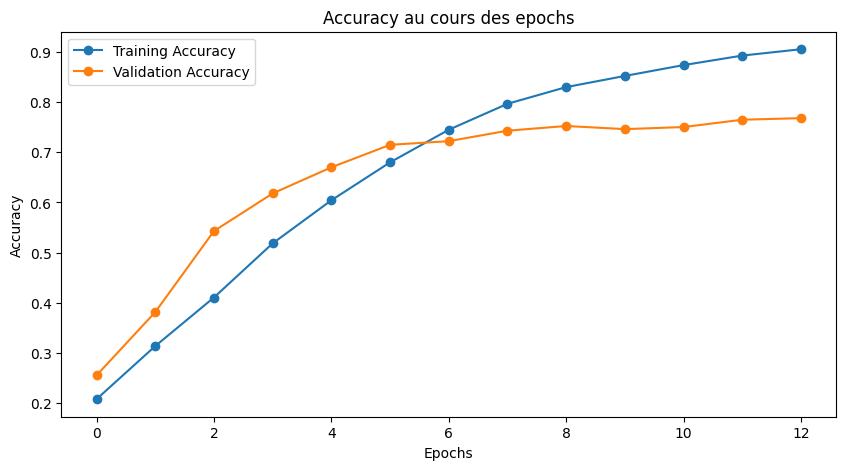

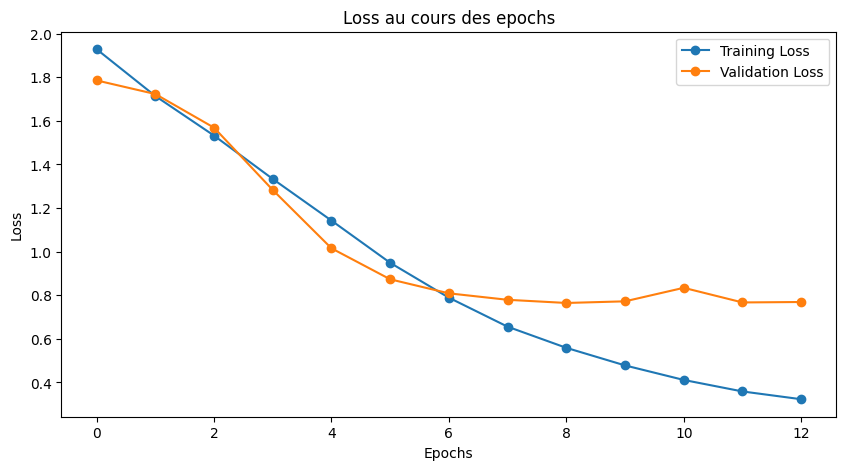

In [13]:
import matplotlib.pyplot as plt

# Afficher la précision
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy au cours des epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Afficher la perte (loss)
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss au cours des epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Matrice de confusion (sur le test)**

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step


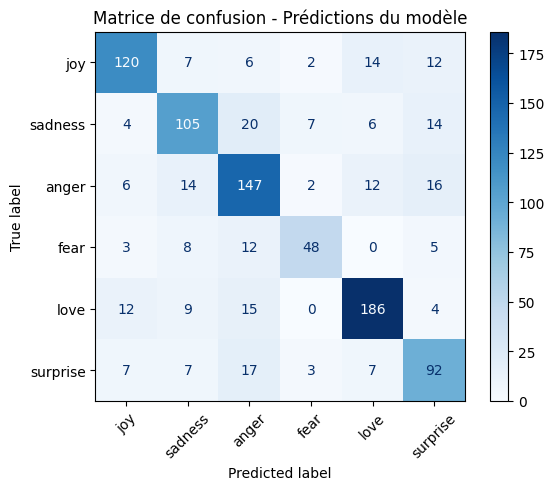

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Prédictions sur le test
y_pred = model.predict(test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matrice de confusion
cm = confusion_matrix(test_labels, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_list)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matrice de confusion - Prédictions du modèle")
plt.show()

In [17]:
import random
import numpy as np

# Choisir 10 indices aléatoires
indices = random.sample(range(len(test_pad)), 10)

# Texte original et séquences correspondantes
sample_texts = test_df['text'].values[indices]
sample_sequences = test_pad[indices]
sample_labels_true = test_labels[indices]

# Prédictions
sample_preds = model.predict(sample_sequences)
sample_labels_pred = np.argmax(sample_preds, axis=1)

# Afficher
for i in range(10):
    print(f"Texte : {sample_texts[i]}")
    print(f"Vraie étiquette : {id2label[sample_labels_true[i]]}")
    print(f"Prédiction du modèle : {id2label[sample_labels_pred[i]]}")
    print("--------------------------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Texte : I love your username...
Vraie étiquette : love
Prédiction du modèle : love
--------------------------------------------------
Texte : [NAME]. Gave up in October and haven’t looked back. I can’t believe how easy I’ve found it.
Vraie étiquette : surprise
Prédiction du modèle : surprise
--------------------------------------------------
Texte : We will welcome you with open arms <3
Vraie étiquette : love
Prédiction du modèle : joy
--------------------------------------------------
Texte : I love that quote, thank you 
Vraie étiquette : love
Prédiction du modèle : love
--------------------------------------------------
Texte : Absolute queens! ❤🏳️‍🌈🏳️‍🌈🏳️‍🌈
Vraie étiquette : love
Prédiction du modèle : love
--------------------------------------------------
Texte : I gotchu bro, house By Gucci Mane I’m a huge Gucci mane fan. 
Vraie étiquette : joy
Prédiction du modèle : sadness
--------------------------------------------------
Texte : They ar